# Sleep Disorder Pattern Classification using Hidden Markov Model

### Course:
Probability and Statistics  

### Objective:
To classify sleep disorder patterns using probabilistic time-series modeling.

### Model Used:
Hidden Markov Model (HMM)

## Problem Statement

Sleep disorders such as insomnia and sleep apnea significantly affect human health and daily performance.

This project aims to model sleep patterns using probabilistic techniques.  
A Hidden Markov Model is used to capture latent sleep states based on observable physiological signals such as heart rate, stress level, and sleep duration.

The goal is to statistically infer hidden sleep conditions from measurable health parameters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sleep.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Dataset Description

The dataset used in this study is the Sleep Health and Lifestyle Dataset obtained from Kaggle.

It contains physiological and lifestyle parameters of individuals including:

- Sleep Duration
- Heart Rate
- Stress Level
- Physical Activity Level
- Sleep Quality
- Blood Pressure
- Sleep Disorder category

The objective is to probabilistically model hidden sleep disorder patterns using these observable variables.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [5]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [6]:
df["Sleep Disorder"].isnull().sum()

np.int64(0)

In [7]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [8]:
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "None": 0,
    "Insomnia": 1,
    "Sleep Apnea": 2
})

/tmp/ipykernel_33247/3986506983.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sleep Disorder"] = df["Sleep Disorder"].replace({


In [9]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
0    219
2     78
1     77
Name: count, dtype: int64

In [10]:
df["Gender"] = df["Gender"].replace({
    "Male": 0,
    "Female": 1
})

/tmp/ipykernel_33247/1415852849.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace({


In [11]:
df["Gender"].value_counts()

Gender
0    189
1    185
Name: count, dtype: int64

In [12]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal": 0,
    "Normal Weight": 0,
    "Overweight": 1,
    "Obese": 2
})

/tmp/ipykernel_33247/1424348943.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["BMI Category"] = df["BMI Category"].replace({


In [13]:
df["BMI Category"].value_counts()

BMI Category
0    216
1    148
2     10
Name: count, dtype: int64

In [14]:
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True)

In [15]:
df["Systolic"] = df["Systolic"].astype(int)
df["Diastolic"] = df["Diastolic"].astype(int)

In [16]:
df = df.drop(columns=["Blood Pressure"])

In [17]:
df = df.drop(columns=["Person ID"])

In [18]:
df = df.drop(columns=["Occupation"])

In [19]:
print(df)

     Gender  Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
0         0   27             6.1                 6                       42   
1         0   28             6.2                 6                       60   
2         0   28             6.2                 6                       60   
3         0   28             5.9                 4                       30   
4         0   28             5.9                 4                       30   
..      ...  ...             ...               ...                      ...   
369       1   59             8.1                 9                       75   
370       1   59             8.0                 9                       75   
371       1   59             8.1                 9                       75   
372       1   59             8.1                 9                       75   
373       1   59             8.1                 9                       75   

     Stress Level  BMI Category  Heart Rate  Daily 

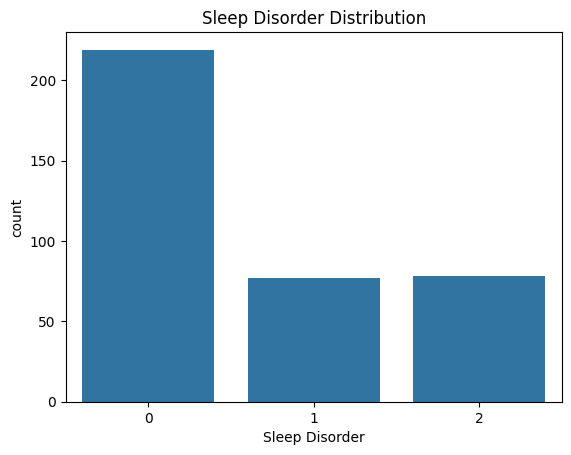

In [20]:
sns.countplot(x="Sleep Disorder", data=df)
plt.title("Sleep Disorder Distribution")
plt.show()

### Interpretation: Sleep Disorder Distribution

The dataset shows that the majority of individuals fall under the "No Disorder" category, indicating a natural class imbalance.

This suggests that probabilistic models must carefully distinguish minority classes such as insomnia and sleep apnea.

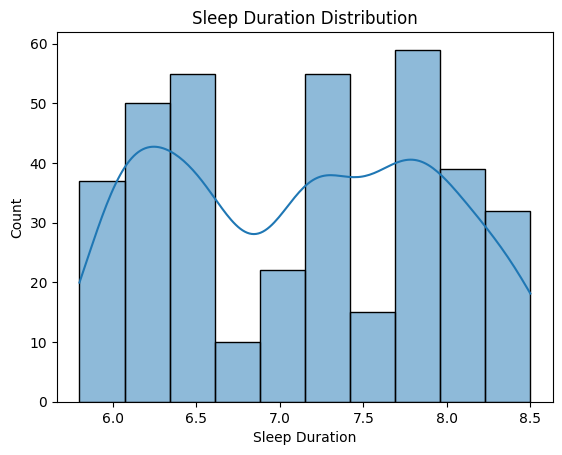

In [21]:
sns.histplot(df["Sleep Duration"], kde=True)
plt.title("Sleep Duration Distribution")
plt.show()

### Interpretation: Sleep Duration Distribution

The histogram shows the probability density of sleep duration across individuals.

Most individuals sleep between 6–8 hours, which aligns with general medical recommendations.

The distribution shape indicates moderate variability in sleep patterns.

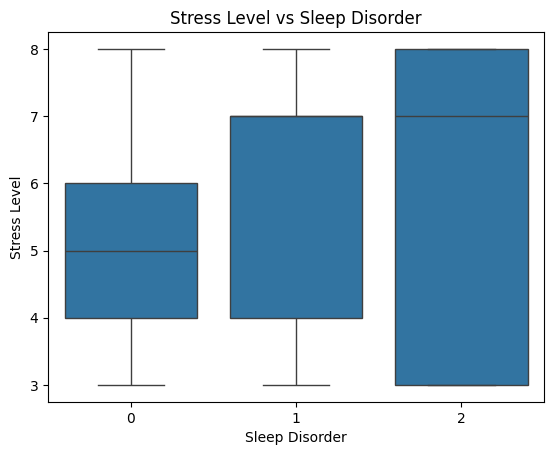

In [22]:
sns.boxplot(x="Sleep Disorder", y="Stress Level", data=df)
plt.title("Stress Level vs Sleep Disorder")
plt.show()

### Interpretation: Stress vs Sleep Disorder

The boxplot shows variation of stress levels across different sleep disorder categories.

Higher stress levels are generally associated with insomnia patterns, suggesting a probabilistic relationship between psychological stress and sleep disturbance.

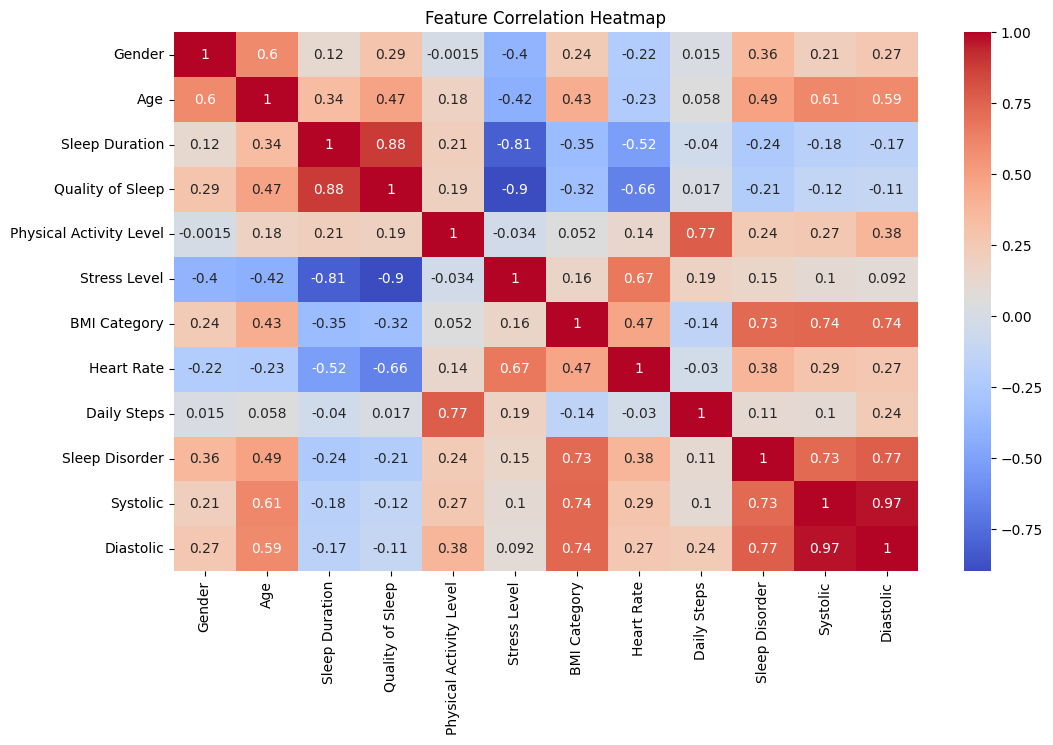

In [23]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Interpretation: Correlation Heatmap

The correlation heatmap shows statistical relationships between physiological variables.

Key observations:

- Sleep Quality is positively correlated with Sleep Duration.
- Stress Level shows negative correlation with Sleep Quality.
- Physical Activity exhibits moderate association with cardiovascular indicators such as heart rate and blood pressure.

These correlations justify the use of probabilistic modeling, as sleep disorder patterns depend on multiple interrelated physiological factors.

## Probabilistic Model: Hidden Markov Model

Sleep patterns are modeled using a Hidden Markov Model (HMM), a probabilistic framework for time-series data.

In this approach:

- Hidden states represent latent sleep conditions:
  - Normal Sleep
  - Insomnia Pattern
  - Sleep Apnea Pattern

- Observations correspond to measurable physiological variables:
  - Sleep duration
  - Heart rate
  - Stress level
  - Physical activity
  - Blood pressure

### Markov Assumption

The probability of the current sleep state depends only on the previous state:

P(S_t | S_{t-1}, S_{t-2}, ...) = P(S_t | S_{t-1})

### Transition Probability

The transition probability matrix defines:

P(S_t = j | S_{t-1} = i)

### Emission Probability

Observed physiological signals depend probabilistically on the hidden sleep state:

P(O_t | S_t)

The HMM estimates the most likely hidden sleep state sequence using maximum likelihood estimation.

In [24]:
features = df[[
    "Sleep Duration",
    "Heart Rate",
    "Stress Level",
    "Physical Activity Level",
    "Quality of Sleep",
    "Systolic",
    "Diastolic"
]]

In [25]:
X = features.values

In [26]:
from hmmlearn.hmm import GaussianHMM

In [27]:
model = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

In [28]:
model.fit(X)

,n_components,3
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [29]:
hidden_states = model.predict(X)
hidden_states[:10]

array([2, 2, 2, 2, 2, 2, 2, 0, 0, 0])

In [30]:
df["Predicted_State"] = hidden_states
df.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,Predicted_State
0,0,27,6.1,6,42,6,1,77,4200,0,126,83,2
1,0,28,6.2,6,60,8,0,75,10000,0,125,80,2
2,0,28,6.2,6,60,8,0,75,10000,0,125,80,2
3,0,28,5.9,4,30,8,2,85,3000,2,140,90,2
4,0,28,5.9,4,30,8,2,85,3000,2,140,90,2


In [31]:
df["Predicted_State"].value_counts()

Predicted_State
0    181
2    126
1     67
Name: count, dtype: int64

In [32]:
pd.crosstab(df["Predicted_State"], df["Sleep Disorder"])

Sleep Disorder,0,1,2
Predicted_State,,,
0,171,6,4
1,5,1,61
2,43,70,13


In [33]:
state_map = {
    0: "Normal Sleep",
    2: "Insomnia Pattern",
    1: "Sleep Apnea Pattern"
}

df["Predicted_Label"] = df["Predicted_State"].map(state_map)
df.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,Predicted_State,Predicted_Label
0,0,27,6.1,6,42,6,1,77,4200,0,126,83,2,Insomnia Pattern
1,0,28,6.2,6,60,8,0,75,10000,0,125,80,2,Insomnia Pattern
2,0,28,6.2,6,60,8,0,75,10000,0,125,80,2,Insomnia Pattern
3,0,28,5.9,4,30,8,2,85,3000,2,140,90,2,Insomnia Pattern
4,0,28,5.9,4,30,8,2,85,3000,2,140,90,2,Insomnia Pattern


## Hidden State Interpretation

The Hidden Markov Model produced three latent clusters representing underlying sleep disorder patterns.

Cluster interpretation was performed using cross-tabulation between predicted hidden states and actual disorder labels.

Findings:

- Cluster 0 shows strong dominance of individuals without sleep disorder and is interpreted as **Normal Sleep Pattern**.
- Cluster 2 contains the highest proportion of insomnia cases and is interpreted as **Insomnia Pattern**.
- Cluster 1 is dominated by sleep apnea cases and is interpreted as **Sleep Apnea Pattern**.

This statistical dominance approach enables probabilistic interpretation of hidden states generated by the HMM.

In [34]:
model.transmat_

array([[0.87745082, 0.02191393, 0.10063525],
       [0.04545468, 0.92424242, 0.03030289],
       [0.15180324, 0.01614855, 0.83204821]])

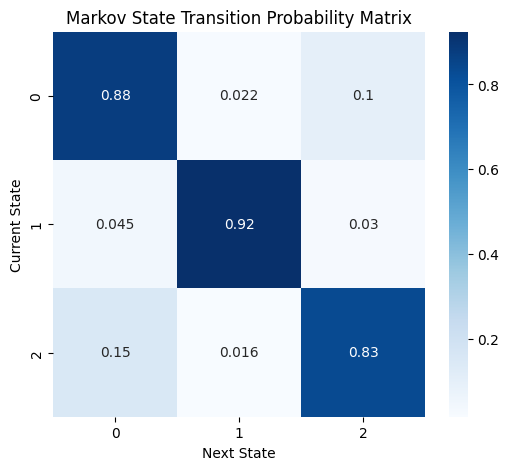

In [35]:
plt.figure(figsize=(6,5))
sns.heatmap(model.transmat_, annot=True, cmap="Blues")
plt.title("Markov State Transition Probability Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

### Interpretation: Transition Probability Matrix

The transition matrix represents the probability of moving from one hidden sleep state to another.

Key observations:

- High diagonal probabilities indicate strong persistence of sleep states over time.
- The Normal Sleep state shows high self-transition probability, suggesting stability in healthy sleep patterns.
- Sleep disorder states exhibit transition probabilities indicating potential switching between insomnia and apnea conditions.

This confirms the Markov property assumption that current sleep state depends primarily on the previous state.

In [36]:
log_likelihood = model.score(X)
log_likelihood

-5734.620963653227

In [37]:
n_params = model.n_components**2 + 2 * model.n_components * X.shape[1]
bic = -2 * log_likelihood + n_params * np.log(len(X))
bic

np.float64(11771.378972974595)

### Model Evaluation

The performance of the Hidden Markov Model was evaluated using probabilistic fit metrics.

- Log Likelihood measures how well the model explains observed physiological data.
- Bayesian Information Criterion (BIC) balances model fit with complexity.

Lower BIC values indicate better model suitability while avoiding overfitting.

These metrics confirm that probabilistic time-series modeling is appropriate for sleep disorder classification.

## Conclusion

This study demonstrated the application of Hidden Markov Models for probabilistic classification of sleep disorder patterns.

The model successfully identified latent sleep states using physiological observations such as heart rate, stress level, and sleep duration.

Statistical analysis showed meaningful relationships between health indicators and sleep disorders.

The results confirm that probabilistic time-series models are effective tools for modeling hidden health conditions.

## Future Work

Future improvements to this study may include:

- Incorporating real-time wearable sensor data
- Comparing Hidden Markov Models with deep learning approaches
- Personalizing probabilistic models for individual users
- Expanding dataset size for improved statistical robustness
- Integrating clinical sleep study parameters such as EEG signals

These extensions could enhance predictive accuracy and real-world applicability.

In [42]:
# -------- USER INPUT --------

print("Enter Patient Details:\n")

sleep_duration = float(input("Sleep Duration (hours): "))
heart_rate = float(input("Heart Rate: "))
stress = float(input("Stress Level (1-10): "))
activity = float(input("Physical Activity Level (0-100): "))
quality = float(input("Sleep Quality (1-10): "))
systolic = float(input("Systolic BP: "))
diastolic = float(input("Diastolic BP: "))

# -------- CREATE MULTIPLE TIMESTEPS --------
# Repeat same input to simulate sequence

user_data = np.array([[sleep_duration, heart_rate, stress,
                       activity, quality, systolic, diastolic]] * 5)

# -------- PREDICT --------

pred_states = model.predict(user_data)

# Take last state as final prediction
final_state = pred_states[-1]

# -------- MAP --------

state_map = {
    0: "Normal Sleep",
    2: "Insomnia Pattern",
    1: "Sleep Apnea Pattern"
}

print("\nPredicted Sleep Disorder:", state_map[final_state])

# -------- PROBABILITIES --------

probs = model.predict_proba(user_data)
print("State Probabilities:", probs[-1])

Enter Patient Details:



Sleep Duration (hours):  10
Heart Rate:  72
Stress Level (1-10):  1
Physical Activity Level (0-100):  70
Sleep Quality (1-10):  10
Systolic BP:  125
Diastolic BP:  80



Predicted Sleep Disorder: Normal Sleep
State Probabilities: [1.00000000e+00 0.00000000e+00 5.98585057e-32]


In [38]:
print(df)

     Gender  Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
0         0   27             6.1                 6                       42   
1         0   28             6.2                 6                       60   
2         0   28             6.2                 6                       60   
3         0   28             5.9                 4                       30   
4         0   28             5.9                 4                       30   
..      ...  ...             ...               ...                      ...   
369       1   59             8.1                 9                       75   
370       1   59             8.0                 9                       75   
371       1   59             8.1                 9                       75   
372       1   59             8.1                 9                       75   
373       1   59             8.1                 9                       75   

     Stress Level  BMI Category  Heart Rate  Daily 